# Corrections

$$E_i=\frac{1}{2}E_{i0}e^{i(k_iz-\omega_it)}+c.c.$$

$$I_i=\frac{1}{2}n_i\epsilon_0c|E_{i0}|^2$$

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x,y,z,t = sp.symbols('x y z t', real = True)
E10, Eshg0 = sp.symbols('E_{10} E_{shg0}')
Eshg0 = sp.Function('E_{shg0}')(z,t)
k1, kshg, delk, om1, omshg, wlshg = sp.symbols('k_1 k_{shg} \\Delta{k} \\omega_1 \\omega_{shg} \\lambda_{shg}',real = True, nonzero=True)
eps0, chi2 = sp.symbols('\\epsilon_0 \\chi^{(2)}', real = True)
n1, nshg, c, L = sp.symbols('n_1 n_{shg} c L', real = True, nonzero=True, positive = True)
xi1,xishg,tau,w0 = sp.symbols('\\xi_1 \\xi_{shg} \\tau w_0', real=True, positive=True)
A1,  Ashg = sp.symbols('A_1 A_{shg}', real=True, positive=True)
I1,  Ishg = sp.symbols('I_1 I_{shg}', real=True, positive=True)
E1,  Eshg = sp.symbols('E_1 E_{shg}', real=True, positive=True)

In [3]:
E1_expr = sp.Rational(1,2)*E10*sp.exp(sp.I*(k1*z-om1*t))
E1_expr = E1_expr + sp.conjugate(E1_expr)
Eshg_expr = sp.Rational(1,2)*Eshg0*sp.exp(sp.I*(kshg*z-omshg*t))
Eshg_expr = Eshg_expr + sp.conjugate(Eshg_expr)
sp.Eq(Eshg,Eshg_expr)

Eq(E_{shg}, E_{shg0}(z, t)*exp(I*(-\omega_{shg}*t + k_{shg}*z))/2 + exp(-I*(-\omega_{shg}*t + k_{shg}*z))*conjugate(E_{shg0}(z, t))/2)

In [4]:
E_tot_expr = E1_expr
P2_tot_expr = (eps0*chi2*E_tot_expr**2).expand()
sel_E2_product_expr = E10*E10
P2_shg_expr = P2_tot_expr.subs(sel_E2_product_expr,1).subs({E10:0})*sel_E2_product_expr
P2_shg_expr = P2_shg_expr.subs(sp.exp(-sp.I*(2*om1)*t).expand(),sp.exp(-sp.I*omshg*t))
sp.Eq(sp.symbols('P^{(2)}_{shg}(t)'),P2_shg_expr)

Eq(P^{(2)}_{shg}(t), E_{10}**2*\chi^{(2)}*\epsilon_0*exp(-I*\omega_{shg}*t)*exp(2*I*k_1*z)/4)

In [5]:
ddEshgdz_expr = sp.diff(Eshg_expr,z,2)
sp.Eq(sp.symbols('\\nabla^2E_{shg}'),ddEshgdz_expr)

Eq(\nabla^2E_{shg}, -k_{shg}**2*E_{shg0}(z, t)*exp(-I*(\omega_{shg}*t - k_{shg}*z))/2 - k_{shg}**2*exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(E_{shg0}(z, t))/2 - I*k_{shg}*exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(Derivative(E_{shg0}(z, t), z)) + I*k_{shg}*exp(-I*(\omega_{shg}*t - k_{shg}*z))*Derivative(E_{shg0}(z, t), z) + exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(Derivative(E_{shg0}(z, t), (z, 2)))/2 + exp(-I*(\omega_{shg}*t - k_{shg}*z))*Derivative(E_{shg0}(z, t), (z, 2))/2)

In [6]:
ddEshgdz_re_expr = ddEshgdz_expr.subs({sp.conjugate(Eshg0):0, sp.diff(sp.conjugate(Eshg0),z,1):0, sp.diff(sp.conjugate(Eshg0),z,2):0}).collect(sp.exp(sp.I*(omshg*t-kshg*z)))
ddEshgdz_re_expr = ddEshgdz_re_expr.subs(sp.diff(Eshg0,z,2),0)
sp.Eq(sp.symbols('\\nabla^2E_{shg}'),ddEshgdz_re_expr)

Eq(\nabla^2E_{shg}, (-k_{shg}**2*E_{shg0}(z, t)/2 + I*k_{shg}*Derivative(E_{shg0}(z, t), z))*exp(-I*(\omega_{shg}*t - k_{shg}*z)))

In [7]:
ddEshgdt_expr = sp.diff(Eshg_expr,t,2)
sp.Eq(sp.symbols('\\frac{\\partial^2E_{shg}}{\\partial{t^2}}'),ddEshgdt_expr)

Eq(\frac{\partial^2E_{shg}}{\partial{t^2}}, -\omega_{shg}**2*E_{shg0}(z, t)*exp(-I*(\omega_{shg}*t - k_{shg}*z))/2 - \omega_{shg}**2*exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(E_{shg0}(z, t))/2 + I*\omega_{shg}*exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(Derivative(E_{shg0}(z, t), t)) - I*\omega_{shg}*exp(-I*(\omega_{shg}*t - k_{shg}*z))*Derivative(E_{shg0}(z, t), t) + exp(I*(\omega_{shg}*t - k_{shg}*z))*conjugate(Derivative(E_{shg0}(z, t), (t, 2)))/2 + exp(-I*(\omega_{shg}*t - k_{shg}*z))*Derivative(E_{shg0}(z, t), (t, 2))/2)

In [8]:
ddEshgdt_re_expr = ddEshgdt_expr.subs({sp.conjugate(Eshg0):0, sp.diff(sp.conjugate(Eshg0),t,1):0, sp.diff(sp.conjugate(Eshg0),t,2):0}).collect(sp.exp(sp.I*(omshg*t-kshg*z)))
ddEshgdt_re_expr = ddEshgdt_re_expr.subs(sp.diff(Eshg0,t,2),0)
sp.Eq(sp.symbols('\\frac{\\partial^2E_{shg}}{\\partial{t^2}}'),ddEshgdt_re_expr)

Eq(\frac{\partial^2E_{shg}}{\partial{t^2}}, (-\omega_{shg}**2*E_{shg0}(z, t)/2 - I*\omega_{shg}*Derivative(E_{shg0}(z, t), t))*exp(-I*(\omega_{shg}*t - k_{shg}*z)))

In [9]:
ddP2_shgdt_expr = sp.diff(P2_shg_expr,t,2).simplify()
sp.Eq(sp.symbols('\\frac{\\partial^2P^{(2)}_{shg}}{\\partial{t^2}}'),ddP2_shgdt_expr)

Eq(\frac{\partial^2P^{(2)}_{shg}}{\partial{t^2}}, -E_{10}**2*\chi^{(2)}*\epsilon_0*\omega_{shg}**2*exp(-I*(\omega_{shg}*t - 2*k_1*z))/4)

In [10]:
#wave equation
we_lhs_expr = (ddEshgdz_re_expr-nshg**2*ddEshgdt_re_expr/c**2)
we_rhs_expr = ddP2_shgdt_expr/eps0/c**2
sp.Eq(we_lhs_expr,we_rhs_expr)

Eq((-k_{shg}**2*E_{shg0}(z, t)/2 + I*k_{shg}*Derivative(E_{shg0}(z, t), z))*exp(-I*(\omega_{shg}*t - k_{shg}*z)) - n_{shg}**2*(-\omega_{shg}**2*E_{shg0}(z, t)/2 - I*\omega_{shg}*Derivative(E_{shg0}(z, t), t))*exp(-I*(\omega_{shg}*t - k_{shg}*z))/c**2, -E_{10}**2*\chi^{(2)}*\omega_{shg}**2*exp(-I*(\omega_{shg}*t - 2*k_1*z))/(4*c**2))

In [11]:
we_lhs_expr = (we_lhs_expr*sp.exp(-sp.I*(kshg*z-omshg*t))*2).expand()
we_rhs_expr = (we_rhs_expr*sp.exp(-sp.I*(kshg*z-omshg*t))*2).expand().simplify()
we_rhs_expr = we_rhs_expr.subs(2*k1-kshg,delk ,nonzero=True)
sp.Eq(we_lhs_expr,we_rhs_expr)

Eq(\omega_{shg}**2*n_{shg}**2*E_{shg0}(z, t)/c**2 + 2*I*\omega_{shg}*n_{shg}**2*Derivative(E_{shg0}(z, t), t)/c**2 - k_{shg}**2*E_{shg0}(z, t) + 2*I*k_{shg}*Derivative(E_{shg0}(z, t), z), -E_{10}**2*\chi^{(2)}*\omega_{shg}**2*exp(I*\Delta{k}*z)/(2*c**2))

In [12]:
#time evolution of Eshg is smaller than spatial evolution
we_lhs_expr = we_lhs_expr.subs(sp.diff(Eshg0,t,1),0)*(-sp.I/2/kshg)
we_rhs_expr = we_rhs_expr*(-sp.I/2/kshg)
sp.Eq(we_lhs_expr,we_rhs_expr)

Eq(-I*(\omega_{shg}**2*n_{shg}**2*E_{shg0}(z, t)/c**2 - k_{shg}**2*E_{shg0}(z, t) + 2*I*k_{shg}*Derivative(E_{shg0}(z, t), z))/(2*k_{shg}), I*E_{10}**2*\chi^{(2)}*\omega_{shg}**2*exp(I*\Delta{k}*z)/(4*c**2*k_{shg}))

In [13]:
#integrate wrt z from 0 to L
we_lhs_int_expr = sp.Integral(we_lhs_expr,(z,0,L)).doit()
we_rhs_int_expr = sp.Integral(we_rhs_expr,(z,0,L)).doit().simplify()
sp.Eq(we_lhs_int_expr,we_rhs_int_expr)

Eq((Integral(2*c**2*k_{shg}*Derivative(E_{shg0}(z, t), z), (z, 0, L)) + Integral(-I*\omega_{shg}**2*n_{shg}**2*E_{shg0}(z, t), (z, 0, L)) + Integral(I*c**2*k_{shg}**2*E_{shg0}(z, t), (z, 0, L)))/(2*c**2*k_{shg}), E_{10}**2*\chi^{(2)}*\omega_{shg}**2*(exp(I*L*\Delta{k}) - 1)/(4*\Delta{k}*c**2*k_{shg}))

In [14]:
#let Eshg(0,t) = 0
we_lhs_int_expr = we_lhs_int_expr.subs(Eshg0.subs(z,0),0)
sp.Eq(we_lhs_int_expr,we_rhs_int_expr)

Eq((Integral(2*c**2*k_{shg}*Derivative(E_{shg0}(z, t), z), (z, 0, L)) + Integral(-I*\omega_{shg}**2*n_{shg}**2*E_{shg0}(z, t), (z, 0, L)) + Integral(I*c**2*k_{shg}**2*E_{shg0}(z, t), (z, 0, L)))/(2*c**2*k_{shg}), E_{10}**2*\chi^{(2)}*\omega_{shg}**2*(exp(I*L*\Delta{k}) - 1)/(4*\Delta{k}*c**2*k_{shg}))

In [15]:
#intensity############################################################
Ishg_expr = sp.Rational(1,2)*nshg*eps0*c*we_rhs_int_expr*sp.conjugate(we_rhs_int_expr)
#intensity############################################################
Ishg_expr = Ishg_expr.subs(E10*sp.conjugate(E10),sp.Abs(E10)**2)
sp.Eq(sp.symbols('I_{shg}'),Ishg_expr)

Eq(I_{shg}, \chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*(-1 + exp(-I*L*\Delta{k}))*(exp(I*L*\Delta{k}) - 1)*Abs(E_{10})**4/(32*\Delta{k}**2*c**3*k_{shg}**2))

In [16]:
temp = sp.exp(sp.I*delk*L)-1
temp = (temp*sp.conjugate(temp)).expand()
temp = temp.subs(sp.exp(sp.I*delk*L),sp.cos(delk*L)+sp.I*sp.sin(delk*L)).simplify()
sp.Eq(sp.Abs(sp.exp(sp.I*delk*L)-1)**2,temp)

Eq(-exp(I*L*\Delta{k}) + 2 - exp(-I*L*\Delta{k}), 4*sin(L*\Delta{k}/2)**2)

In [17]:
Ishg_expr2 = Ishg_expr.subs(sp.exp(sp.I*delk*L),sp.cos(delk*L)+sp.I*sp.sin(delk*L)).simplify()
sp.Eq(Ishg,Ishg_expr2)

Eq(I_{shg}, \chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*sin(L*\Delta{k}/2)**2*Abs(E_{10})**4/(8*\Delta{k}**2*c**3*k_{shg}**2))

In [18]:
###################REWRITE ABOVE RESULT##########################
Ishg_expr3 = chi2**2*eps0*omshg**4*nshg*sp.Abs(E10)**4*sp.sin(L*delk/2)**2/(32*delk**2*c**3*kshg**2)
sp.Eq(sp.symbols('I_{shg}'),Ishg_expr3)

Eq(I_{shg}, \chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*sin(L*\Delta{k}/2)**2*Abs(E_{10})**4/(32*\Delta{k}**2*c**3*k_{shg}**2))

In [19]:
Ishg_in_E_expr = Ishg_expr3.subs(sp.sin(L*delk/2)**2,(L*delk/2)**2*sp.sinc(L*delk/2)**2)
sp.Eq(sp.symbols('I_{shg}'),Ishg_in_E_expr)

Eq(I_{shg}, L**2*\chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*Abs(E_{10})**4*sinc(L*\Delta{k}/2)**2/(128*c**3*k_{shg}**2))

In [20]:
E10_expr = A1*sp.exp(-2*sp.log(2)*t**2/tau**2)*sp.exp(-(x**2+y**2)/w0**2)
sp.Eq(E10, E10_expr)

Eq(E_{10}, A_1*exp((-x**2 - y**2)/w_0**2)*exp(-2*t**2*log(2)/\tau**2))

In [21]:
Ishg_in_A_expr = Ishg_in_E_expr.subs({E10:E10_expr})
sp.Eq(sp.symbols('I_{shg}'),Ishg_in_A_expr)

Eq(I_{shg}, A_1**4*L**2*\chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*exp(-4*(x**2 + y**2)/w_0**2)*exp(-8*t**2*log(2)/\tau**2)*sinc(L*\Delta{k}/2)**2/(128*c**3*k_{shg}**2))

In [22]:
sp.Eq(xishg, sp.Integral(sp.Integral(sp.Integral(Ishg,(t,-sp.oo,sp.oo)),(x,-sp.oo,sp.oo)),(y,-sp.oo,sp.oo)))

Eq(\xi_{shg}, Integral(I_{shg}, (t, -oo, oo), (x, -oo, oo), (y, -oo, oo)))

In [23]:
int1 = sp.Integral(sp.Integral(sp.Integral(sp.exp(-8*sp.log(2)*t**2/tau**2)*sp.exp(-4*(x**2+y**2)/w0**2),(t,-sp.oo,sp.oo)),(x,-sp.oo,sp.oo)),(y,-sp.oo,sp.oo))
sp.Eq(int1,int1.doit())

Eq(Integral(exp((-4*x**2 - 4*y**2)/w_0**2)*exp(-8*t**2*log(2)/\tau**2), (t, -oo, oo), (x, -oo, oo), (y, -oo, oo)), sqrt(2)*pi**(3/2)*\tau*w_0**2/(16*sqrt(log(2))))

In [24]:
xishg_expr = sp.Integral(sp.Integral(sp.Integral(Ishg_in_A_expr,(t,-sp.oo,sp.oo)),(x,-sp.oo,sp.oo)),(y,-sp.oo,sp.oo))
sp.Eq(xishg, xishg_expr)

Eq(\xi_{shg}, Integral(A_1**4*L**2*\chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*n_{shg}*exp(-4*(x**2 + y**2)/w_0**2)*exp(-8*t**2*log(2)/\tau**2)*sinc(L*\Delta{k}/2)**2/(128*c**3*k_{shg}**2), (t, -oo, oo), (x, -oo, oo), (y, -oo, oo)))

In [25]:
xishg_expr = xishg_expr.doit()
sp.Eq(xishg, xishg_expr)

Eq(\xi_{shg}, sqrt(2)*pi**(3/2)*A_1**4*L**2*\chi^{(2)}**2*\epsilon_0*\omega_{shg}**4*\tau*n_{shg}*w_0**2*sinc(L*\Delta{k}/2)**2/(2048*c**3*k_{shg}**2*sqrt(log(2))))

In [26]:
#intensity############################################################
I1_in_E_expr = sp.Rational(1,2)*n1*eps0*c*sp.Abs(E10)**2
#intensity############################################################
sp.Eq(I1, I1_in_E_expr)

Eq(I_1, \epsilon_0*c*n_1*Abs(E_{10})**2/2)

In [27]:
E10_abs_sq_in_I_expr = I1/I1_in_E_expr*sp.Abs(E10)**2
sp.Eq(sp.Abs(E10)**2, E10_abs_sq_in_I_expr)

Eq(Abs(E_{10})**2, 2*I_1/(\epsilon_0*c*n_1))

In [28]:
Ishg_in_I_expr = sp.simplify(Ishg_in_E_expr/sp.Abs(E10)**4)*E10_abs_sq_in_I_expr**4
sp.Eq(Ishg,Ishg_in_I_expr)

Eq(I_{shg}, I_1**4*L**2*\chi^{(2)}**2*\omega_{shg}**4*n_{shg}*sinc(L*\Delta{k}/2)**2/(8*\epsilon_0**3*c**7*k_{shg}**2*n_1**4))

In [29]:
I1_in_A_expr = I1_in_E_expr.subs(E10,E10_expr)
sp.Eq(I1, I1_in_A_expr)

Eq(I_1, A_1**2*\epsilon_0*c*n_1*exp(-2*(x**2 + y**2)/w_0**2)*exp(-4*t**2*log(2)/\tau**2)/2)

In [30]:
xi1_expr = sp.Integral(sp.Integral(sp.Integral(I1_in_A_expr,(t,-sp.oo,sp.oo)),(x,-sp.oo,sp.oo)),(y,-sp.oo,sp.oo))
sp.Eq(xi1, xi1_expr)

Eq(\xi_1, Integral(A_1**2*\epsilon_0*c*n_1*exp(-2*(x**2 + y**2)/w_0**2)*exp(-4*t**2*log(2)/\tau**2)/2, (t, -oo, oo), (x, -oo, oo), (y, -oo, oo)))

In [31]:
xi1_expr = xi1_expr.doit()
sp.Eq(xi1, xi1_expr)

Eq(\xi_1, pi**(3/2)*A_1**2*\epsilon_0*\tau*c*n_1*w_0**2/(8*sqrt(log(2))))

In [32]:
xishg_expr_f = xishg_expr*(xi1**2/xi1_expr**2)
sp.Eq(xishg, xishg_expr_f)

Eq(\xi_{shg}, sqrt(2)*L**2*\chi^{(2)}**2*\omega_{shg}**4*\xi_1**2*n_{shg}*sqrt(log(2))*sinc(L*\Delta{k}/2)**2/(32*pi**(3/2)*\epsilon_0*\tau*c**5*k_{shg}**2*n_1**2*w_0**2))

In [33]:
xishg_expr_ff = xishg_expr_f.subs(kshg,nshg*omshg/c)
sp.Eq(xishg, xishg_expr_ff)

Eq(\xi_{shg}, sqrt(2)*L**2*\chi^{(2)}**2*\omega_{shg}**2*\xi_1**2*sqrt(log(2))*sinc(L*\Delta{k}/2)**2/(32*pi**(3/2)*\epsilon_0*\tau*c**3*n_1**2*n_{shg}*w_0**2))

In [34]:
xishg_expr_fff = xishg_expr_ff.subs(omshg,2*sp.pi*c/wlshg)
sp.Eq(xishg, xishg_expr_fff)

Eq(\xi_{shg}, sqrt(2)*sqrt(pi)*L**2*\chi^{(2)}**2*\xi_1**2*sqrt(log(2))*sinc(L*\Delta{k}/2)**2/(8*\epsilon_0*\lambda_{shg}**2*\tau*c*n_1**2*n_{shg}*w_0**2))

In [35]:
P1_val = 100e-3 # power in W (100 mW)
tau1_val = 100e-15  # seconds
f_rep = 76e6  # repetition rate in Hz (76 MHz)
xi1_val = P1_val/f_rep
sp.Eq(xi1, xi1_val)

Eq(\xi_1, 1.31578947368421e-9)

In [36]:
w0_val = (200e-9)/2  # meters (200 nm)
chi2_val = 1e-12  # m/V
L_val = 200e-9  # meters (200 nm)
wlshg_val = 800e-9  # meters
n1_val, nshg_val = 2.5, 2.5  # refractive indices
delk_val = 0  # phase mismatch
eps0_val = 8.854187817e-12  # F/m
c_val = 3e8  # m/s

xishg_num = xishg_expr_fff.evalf(subs={tau:tau1_val, w0:w0_val, chi2:chi2_val, L:L_val, wlshg:wlshg_val, n1:n1_val, nshg:nshg_val, xi1:xi1_val, delk:delk_val, eps0:eps0_val, c:c_val})
sp.Eq(xishg, xishg_num)

Eq(\xi_{shg}, 6.8010426704695e-16)

In [37]:
h_bar = 1.0545718e-34  # J·s
omega_as_val = 2*sp.pi*c_val/wlshg_val  # rad/s
N_photons_per_pulse = (xishg_num/(h_bar*omega_as_val)).evalf()
sp.Eq(sp.symbols('N_{photons\\,per\\,pulse}'), int(sp.N(N_photons_per_pulse).round(0)))

Eq(N_{photons,per,pulse}, 2737)

In [38]:
produced_photon_flux = N_photons_per_pulse*f_rep
sp.Eq(sp.symbols('Flux_{produced}[photons/s]'), sp.Float(produced_photon_flux,3))

Eq(Flux_{produced}[photons/s], 2.08e+11)

In [39]:
QE_factor = 0.58 # quantum efficiency of detector (58%)
loss_factor = 0.1 # losses in the system (~10%)
int_time_num = 100e-3  # integration time in seconds (100 ms)
detected_counts = produced_photon_flux*QE_factor*(1-loss_factor)*int_time_num
sp.Eq(sp.symbols('Counts_{detected}'), sp.Float(detected_counts,3))

Eq(Counts_{detected}, 1.09e+10)

In [40]:
xishg_expr_fff

sqrt(2)*sqrt(pi)*L**2*\chi^{(2)}**2*\xi_1**2*sqrt(log(2))*sinc(L*\Delta{k}/2)**2/(8*\epsilon_0*\lambda_{shg}**2*\tau*c*n_1**2*n_{shg}*w_0**2)

In [41]:
xishg_func = sp.lambdify((chi2, w0, L, wlshg, n1, nshg, xi1, delk, eps0, c, tau), xishg_expr_fff)   # default uses Python math

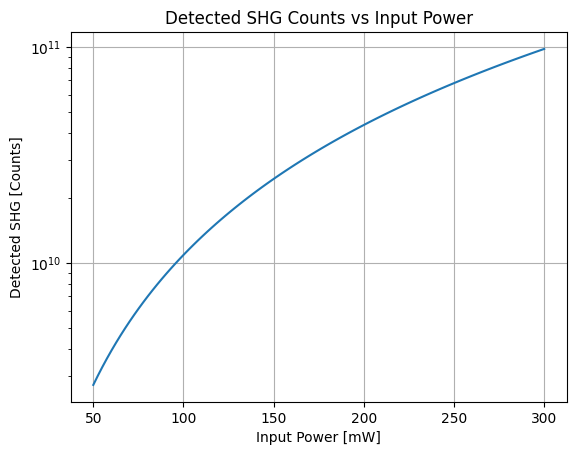

In [42]:
P1_arr = np.linspace(50, 300, 100) * 1e-3  # power in W (100 mW)
xi1_val = P1_arr/f_rep
xishg_arr = xishg_func(chi2_val, w0_val, L_val, wlshg_val, n1_val, nshg_val, xi1_val, delk_val, eps0_val, c_val, tau1_val)
omega_as_val = 2*np.pi*c_val/wlshg_val  # rad/s
N_photons_per_pulse = (xishg_arr/(h_bar*omega_as_val))
produced_photon_flux = N_photons_per_pulse*f_rep
detected_counts = produced_photon_flux*QE_factor*(1-loss_factor)*int_time_num

plt.Figure(figsize=(8,6))
plt.plot(P1_arr*1e3, detected_counts)
plt.yscale('log'); plt.title('Detected SHG Counts vs Input Power')
plt.xlabel('Input Power [mW]'); plt.ylabel('Detected SHG [Counts]')
plt.grid(); plt.show()

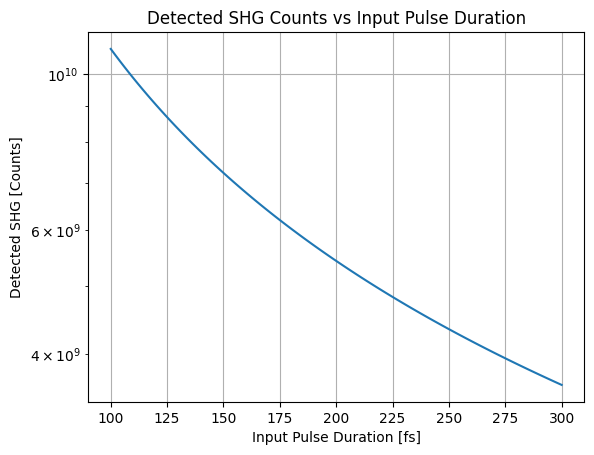

In [43]:
P1_val = 100e-3  # power in W (100 mW)
xi1_val = P1_val/f_rep
tau1_val = np.linspace(100, 300, 100) * 1e-15  # seconds
xishg_arr = xishg_func(chi2_val, w0_val, L_val, wlshg_val, n1_val, nshg_val, xi1_val, delk_val, eps0_val, c_val, tau1_val)
omega_as_val = 2*np.pi*c_val/wlshg_val  # rad/s
N_photons_per_pulse = (xishg_arr/(h_bar*omega_as_val))
produced_photon_flux = N_photons_per_pulse*f_rep
detected_counts = produced_photon_flux*QE_factor*(1-loss_factor)*int_time_num

plt.Figure(figsize=(8,6))
plt.plot(tau1_val*1e15, detected_counts)
plt.yscale('log'); plt.title('Detected SHG Counts vs Input Pulse Duration')
plt.xlabel('Input Pulse Duration [fs]'); plt.ylabel('Detected SHG [Counts]')
plt.grid(); plt.show()

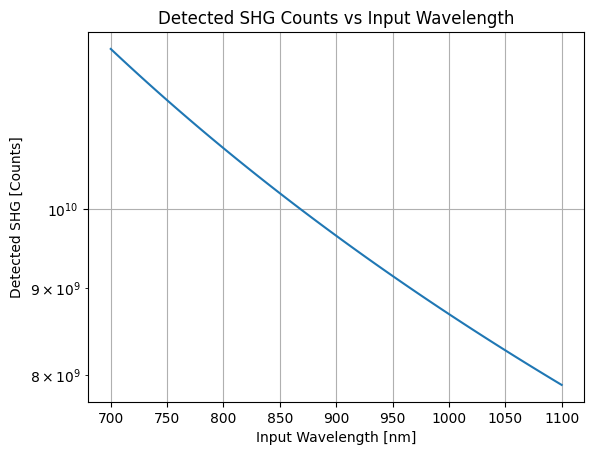

In [44]:
P1_val = 100e-3  # power in W (100 mW)
xi1_val = P1_val/f_rep
tau1_val = 100e-15  # seconds
wlshg_val = np.linspace(700, 1100, 100) * 1e-9  # wavelength in m
xishg_arr = xishg_func(chi2_val, w0_val, L_val, wlshg_val, n1_val, nshg_val, xi1_val, delk_val, eps0_val, c_val, tau1_val)
omega_as_val = 2*np.pi*c_val/wlshg_val  # rad/s
N_photons_per_pulse = (xishg_arr/(h_bar*omega_as_val))
produced_photon_flux = N_photons_per_pulse*f_rep
detected_counts = produced_photon_flux*QE_factor*(1-loss_factor)*int_time_num

plt.Figure(figsize=(8,6))
plt.plot(wlshg_val*1e9, detected_counts)
plt.yscale('log'); plt.title('Detected SHG Counts vs Input Wavelength')
plt.xlabel('Input Wavelength [nm]'); plt.ylabel('Detected SHG [Counts]')
plt.grid(); plt.show()